# PV Fault Classification from Infrared Images

This project evaluates validation-selected logit adjustment for a fixed ImageNet-pretrained ResNet-18 classifier using the public InfraredSolarModules dataset.

Dataset: https://github.com/RaptorMaps/InfraredSolarModules

The study addresses the following research questions:

1. Does validation-selected logit adjustment improve macro-F1, balanced accuracy, and recall for rare PV fault classes?
2. What effect does the adjustment have on overall classification accuracy?
3. Which PV fault classes benefit from the adjustment, and which classes remain difficult to classify?

The analysis uses one documented data split and one trained ResNet-18 checkpoint. Results are presented through quantitative metrics, class-level comparisons, error analysis, and a qualitative model-interpretation example.

## Setup

The required libraries, random seed, paths, device, and experiment settings are defined before the analysis.

In [1]:
import importlib.util
import subprocess
import sys

required = {
    "seaborn": "seaborn>=0.13,<1",
    "sklearn": "scikit-learn>=1.4,<2",
    "tqdm": "tqdm>=4.66,<5",
}
missing = [
    package
    for module, package in required.items()
    if importlib.util.find_spec(module) is None
]
if missing:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        *missing,
    ])

In [2]:
import hashlib
import json
import platform
import random
import sys
import time
import urllib.request
import zipfile
from copy import deepcopy
from importlib.metadata import version as package_version
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    recall_score,
)
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import ResNet18_Weights, resnet18
from tqdm import tqdm

sns.set_theme(style="whitegrid")

In [3]:
SEED = 42
QUICK_RUN = False
IMAGE_SIZE = 128
BATCH_SIZE = 128
EPOCHS = 3 if not QUICK_RUN else 1
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0
TAU_VALUES = np.arange(0.0, 1.51, 0.1)
BOOTSTRAP_ITERATIONS = 2_000
RARE_CLASSES = {"Diode-Multi", "Hot-Spot", "Hot-Spot-Multi", "Soiling"}


In [ ]:
BASE_DIR = Path("/content") if Path("/content").exists() else Path("/tmp")
WORK_DIR = BASE_DIR / "pv_fault_colab"
DATA_DIR = WORK_DIR / "InfraredSolarModules"
OUTPUT_DIR = WORK_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [4]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


In [5]:
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"Selected device: {DEVICE}")

Selected device: mps


In [ ]:
set_seed(SEED)
print(f"Random seeds initialized to {SEED}.")

## Data Preparation

The analysis uses the public InfraredSolarModules dataset, which contains infrared images from 12 PV fault classes.

In [6]:
DATASET_URL = (
    "https://raw.githubusercontent.com/RaptorMaps/InfraredSolarModules/"
    "88e2d1febbcefe401c17ec80b8973f36a02a1653/"
    "2020-02-14_InfraredSolarModules.zip"
)
EXPECTED_SHA256 = "b82c706bc719b045ac4f8930570d81767a8a170d0998ca3e09283b585db05b5e"
ARCHIVE_PATH = WORK_DIR / "InfraredSolarModules.zip"
METADATA_PATH = DATA_DIR / "module_metadata.json"


In [7]:
WORK_DIR.mkdir(parents=True, exist_ok=True)
if not ARCHIVE_PATH.exists():
    print("Downloading official InfraredSolarModules archive...")
    urllib.request.urlretrieve(DATASET_URL, ARCHIVE_PATH)

digest = hashlib.sha256(ARCHIVE_PATH.read_bytes()).hexdigest()
if digest != EXPECTED_SHA256:
    raise RuntimeError(f"Dataset checksum mismatch: {digest}")

print("Dataset archive is present and checksum verified.")

In [ ]:
if not METADATA_PATH.exists():
    destination = WORK_DIR.resolve()
    with zipfile.ZipFile(ARCHIVE_PATH) as archive:
        for member in archive.infolist():
            member_path = (WORK_DIR / member.filename).resolve()
            if member_path != destination and destination not in member_path.parents:
                raise RuntimeError(
                    f"Unsafe archive member path: {member.filename}"
                )
        archive.extractall(WORK_DIR)

In [ ]:
image_count = len(list((DATA_DIR / "images").glob("*.jpg")))
print(f"Dataset ready: {image_count:,} images.")

### Dataset Inspection

In [8]:
# Load metadata and class labels
with METADATA_PATH.open("r", encoding="utf-8") as handle:
    raw_metadata = json.load(handle)

rows = []
for image_id, record in raw_metadata.items():
    relative_path = Path(record["image_filepath"])
    rows.append({
        "image_id": int(image_id),
        "image_filepath": relative_path.as_posix(),
        "label": record["anomaly_class"],
        "absolute_path": str(DATA_DIR / relative_path),
    })
metadata_df = pd.DataFrame(rows).sort_values("image_id").reset_index(drop=True)



print(f"Loaded {len(metadata_df):,} metadata records across {metadata_df['label'].nunique()} classes.")
display(
    metadata_df["label"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="records")
)


Loaded 20,000 metadata records across 12 classes.


,label,records
0,No-Anomaly,10000
1,Cell,1877
2,Vegetation,1639
3,Diode,1499
4,Cell-Multi,1288
5,Shadowing,1056
6,Cracking,940
7,Offline-Module,827
8,Hot-Spot,249
9,Hot-Spot-Multi,246


In [ ]:
# Inspect metadata structure and one image
print(
    f"Metadata table: {metadata_df.shape[0]:,} rows x "
    f"{metadata_df.shape[1]} columns"
)
print("Columns:", ", ".join(metadata_df.columns))
display(metadata_df.head(10))
display(metadata_df.dtypes.rename("dtype").to_frame())

sample_path = Path(metadata_df.iloc[0]["absolute_path"])
with Image.open(sample_path) as sample_image:
    print(
        f"Example image: size={sample_image.size}, "
        f"mode={sample_image.mode}"
    )

In [9]:
# Define the image-content hash used for duplicate checks
def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

In [10]:
# Verify that all metadata-linked image files are present
missing_paths = [
    path
    for path in metadata_df["absolute_path"]
    if not Path(path).exists()
]
if missing_paths:
    raise FileNotFoundError(
        f"Missing {len(missing_paths)} metadata-linked images."
    )

print(f"Validated {len(metadata_df):,} metadata-linked image paths.")

Validated 20,000 metadata-linked image paths.


In [11]:
# Load previously computed image hashes when available
hash_cache_path = WORK_DIR / "image_sha256.csv"
hash_df = None
if hash_cache_path.exists():
    cached = pd.read_csv(hash_cache_path)
    required_columns = {"image_id", "sha256"}
    expected_ids = set(metadata_df["image_id"])
    cache_is_valid = (
        required_columns.issubset(cached.columns)
        and len(cached) == len(metadata_df)
        and not cached["image_id"].duplicated().any()
        and set(cached["image_id"]) == expected_ids
        and cached["sha256"]
        .astype(str)
        .str.fullmatch(r"[0-9a-f]{64}")
        .all()
    )
    if cache_is_valid:
        hash_df = cached[["image_id", "sha256"]].copy()

cache_status = "valid cache found" if hash_df is not None else "hashing required"
print(f"SHA-256 cache check: {cache_status}.")

SHA-256 cache check: valid cache found.


In [12]:
# Compute hashes for image files that are not already cached
if hash_df is None:
    hash_df = metadata_df[["image_id", "absolute_path"]].copy()
    hash_df["sha256"] = [
        sha256_file(path)
        for path in tqdm(
            hash_df["absolute_path"],
            desc="Hashing images",
        )
    ]
    hash_df[["image_id", "sha256"]].to_csv(
        hash_cache_path,
        index=False,
    )
    print(f"Saved {len(hash_df):,} image hashes to cache.")

In [13]:
# Attach image-content hashes to the metadata
image_df = metadata_df.merge(
    hash_df[["image_id", "sha256"]],
    on="image_id",
    how="left",
    validate="one_to_one",
)
assert image_df["sha256"].notna().all()

print(f"Unique image hashes: {image_df['sha256'].nunique():,}")

Unique image hashes: 19,978


### Duplicate Records

In [14]:
# Identify exact duplicate image groups
duplicate_summary = (
    image_df.groupby("sha256")
    .agg(
        count=("image_id", "size"),
        label_count=("label", "nunique"),
    )
    .query("count > 1")
    .reset_index()
)
conflicting_hashes = set(
    duplicate_summary.loc[
        duplicate_summary["label_count"] > 1,
        "sha256",
    ]
)
duplicate_records = image_df[
    image_df["sha256"].isin(duplicate_summary["sha256"])
]

In [ ]:
print(f"Duplicate groups found: {len(duplicate_summary)}")
print(f"Groups with conflicting labels: {len(conflicting_hashes)}")
display(
    duplicate_summary.sort_values(
        ["label_count", "count"],
        ascending=False,
    ).head(10)
)

In [15]:
# Apply the duplicate-record policy
keep_ids = set(image_df["image_id"])
excluded_rows = []
for sha256, group in duplicate_records.groupby("sha256"):
    ids = sorted(group["image_id"].tolist())
    if sha256 in conflicting_hashes:
        for image_id in ids:
            keep_ids.discard(image_id)
            excluded_rows.append({
                "image_id": image_id,
                "sha256": sha256,
                "reason": "conflicting_duplicate_label",
            })
    else:
        for image_id in ids[1:]:
            keep_ids.discard(image_id)
            excluded_rows.append({
                "image_id": image_id,
                "sha256": sha256,
                "reason": "same_label_duplicate_extra",
            })

In [16]:
# Summarise the records retained for modelling
modelling_df = image_df[image_df["image_id"].isin(keep_ids)].copy()
excluded_df = pd.DataFrame(excluded_rows)

print(f"Exact duplicate groups: {len(duplicate_summary)}")
print(f"Conflicting-label duplicate groups: {len(conflicting_hashes)}")
print(f"Records excluded by duplicate policy: {len(excluded_df)}")
display(duplicate_summary.head(10))

Exact duplicate groups: 22
Conflicting-label duplicate groups: 6
Records excluded by duplicate policy: 28


,sha256,count,label_count
0,262abc63c9edfc2749163b45fe6ba4e53438ce7890e486...,2,1
1,31322a29f5580661a71b2bece539ad93bd52c5f76105d5...,2,2
2,586d3653be12c6377f0f9820a0332e506416ce209785ef...,2,1
3,58817e86a107a0a7245aadb4834d4d92dd9f7559f3f72d...,2,1
4,6a892e426de8c4352b2a30f89a6324e458416056b5d0b8...,2,1
5,715c52c80c6207fa3c1105007132adcd8704e4b1db81b8...,2,1
6,819984dfdb7b8db8a9fd92364984c27c78149a6515f879...,2,1
7,9f3c7dd58fc3e1db1545da20ca5605fafd7736ca6b6121...,2,1
8,a97285f851010305f5b6363fa6be345dddbbb2dc0a4075...,2,1
9,b1cb94dc8a1359b16adcca1c9df33706ab993ac4acbcaf...,2,2


In [17]:
def create_stratified_splits(frame, seed=42):
    rng = np.random.default_rng(seed)
    parts = {"train": [], "validation": [], "test": []}
    for _, group in frame.groupby("label", sort=True):
        shuffled = group.iloc[rng.permutation(len(group))].reset_index(drop=True)
        n_train = int(round(len(shuffled) * 0.70))
        n_validation = int(round(len(shuffled) * 0.15))
        parts["train"].append(shuffled.iloc[:n_train])
        parts["validation"].append(shuffled.iloc[n_train:n_train + n_validation])
        parts["test"].append(shuffled.iloc[n_train + n_validation:])
    return {
        name: pd.concat(group_parts, ignore_index=True).sort_values("image_id").reset_index(drop=True)
        for name, group_parts in parts.items()
    }


### Data Splits

In [18]:
# Create class-stratified train, validation, and test splits
splits = create_stratified_splits(modelling_df, SEED)
if QUICK_RUN:
    limits = {"train": 120, "validation": 40, "test": 40}
    splits = {
        name: pd.concat([
            group.sample(
                min(len(group), limits[name]),
                random_state=SEED,
            )
            for _, group in frame.groupby("label", sort=True)
        ], ignore_index=True)
        for name, frame in splits.items()
    }

print(
    "Split sizes: "
    + ", ".join(
        f"{name}={len(frame):,}"
        for name, frame in splits.items()
    )
)

Split sizes: train=13,981, validation=2,996, test=2,995


In [19]:
# Verify class coverage and duplicate separation across splits
split_hashes = {
    name: set(frame["sha256"])
    for name, frame in splits.items()
}
assert split_hashes["train"].isdisjoint(split_hashes["validation"])
assert split_hashes["train"].isdisjoint(split_hashes["test"])
assert split_hashes["validation"].isdisjoint(split_hashes["test"])
assert (
    set(splits["train"]["label"])
    == set(splits["validation"]["label"])
    == set(splits["test"]["label"])
)

print("Split checks passed: class coverage and content hashes are disjoint.")

Split checks passed: class coverage and content hashes are disjoint.


In [ ]:
# Display split sizes and sample records
split_overview = pd.DataFrame({
    "records": {name: len(frame) for name, frame in splits.items()},
    "classes": {name: frame["label"].nunique() for name, frame in splits.items()},
    "unique_images": {name: frame["image_id"].nunique() for name, frame in splits.items()},
}).rename_axis("split")
display(split_overview)

for name, frame in splits.items():
    print(f"{name.title()} split sample:")
    display(frame[["image_id", "image_filepath", "label"]].head(3))

In [20]:
for name, frame in splits.items():
    frame.drop(
        columns=["absolute_path"],
        errors="ignore",
    ).to_csv(
        OUTPUT_DIR / f"{name}_split.csv",
        index=False,
    )
duplicate_summary.to_csv(
    OUTPUT_DIR / "duplicate_groups.csv",
    index=False,
)
excluded_df.to_csv(
    OUTPUT_DIR / "excluded_duplicate_records.csv",
    index=False,
)

print(f"Saved split manifests and duplicate audit to {OUTPUT_DIR}.")

Saved split manifests and duplicate audit to /tmp/pv_fault_colab/outputs.


In [21]:
summary = {
    "metadata_records": len(metadata_df),
    "unique_image_hashes": int(image_df["sha256"].nunique()),
    "duplicate_groups": len(duplicate_summary),
    "conflicting_duplicate_groups": len(conflicting_hashes),
    "excluded_records": len(excluded_df),
    **{
        f"{name}_records": len(frame)
        for name, frame in splits.items()
    },
}
display(pd.Series(summary, name="value").to_frame())
display(
    pd.crosstab(
        splits["train"]["label"],
        columns="train_count",
    ).sort_values("train_count")
)

,value
metadata_records,20000
unique_image_hashes,19978
duplicate_groups,22
conflicting_duplicate_groups,6
excluded_records,28
train_records,13981
validation_records,2996
test_records,2995


col_0,train_count
label,
Diode-Multi,122
Soiling,143
Hot-Spot-Multi,172
Hot-Spot,174
Offline-Module,575
Cracking,656
Shadowing,732
Cell-Multi,900
Diode,1047


### Data Summary

The metadata contain 20,000 records and 19,978 unique image hashes. The duplicate policy excludes 28 records, leaving 19,972 records for modelling. The final split contains 13,981 training records, 2,996 validation records, and 2,995 test records. All splits contain every class, and no exact image hash appears in more than one split.

The duplicate check identifies exact duplicate files only. It does not establish that visually similar images or images from the same site are absent.

## Data Exploration

The training split is examined using class counts and representative images. These plots describe the data and are not performance results.

### Class Balance

The training data are imbalanced: the No-Anomaly class contains 7,000 records, while the four rare classes contain 122 to 174 records each. Accuracy can therefore be dominated by the most common class. Macro-F1, balanced accuracy, rare-class recall, and per-class precision are also reported.

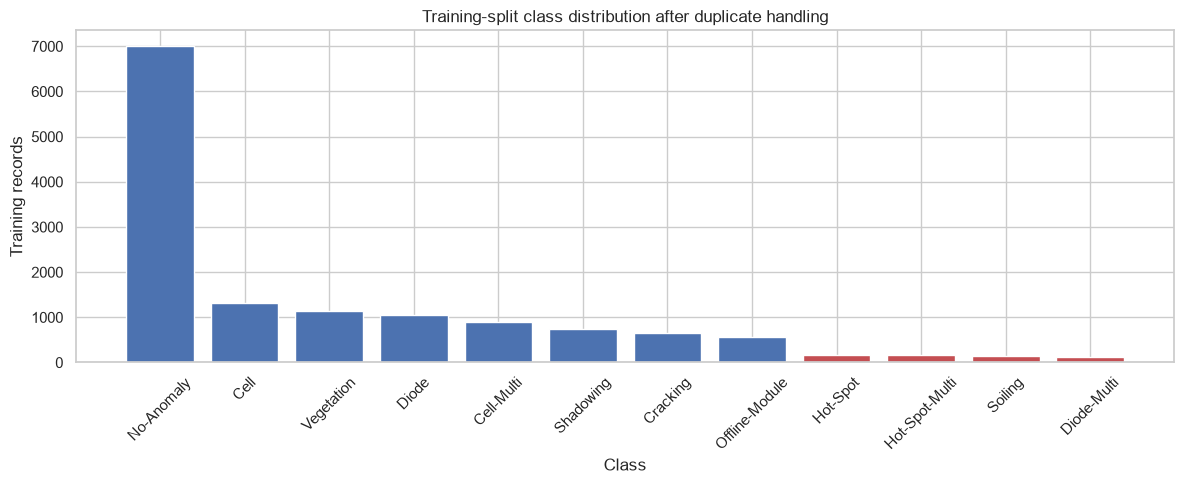

In [22]:
eda_df = splits["train"]
class_counts = eda_df["label"].value_counts().sort_values(ascending=False)
colors = [
    "#c44e52" if label in RARE_CLASSES else "#4c72b0"
    for label in class_counts.index
]
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(class_counts.index, class_counts.values, color=colors)
ax.set(
    title="Training-split class distribution after duplicate handling",
    xlabel="Class",
    ylabel="Training records",
)
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "class_distribution.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

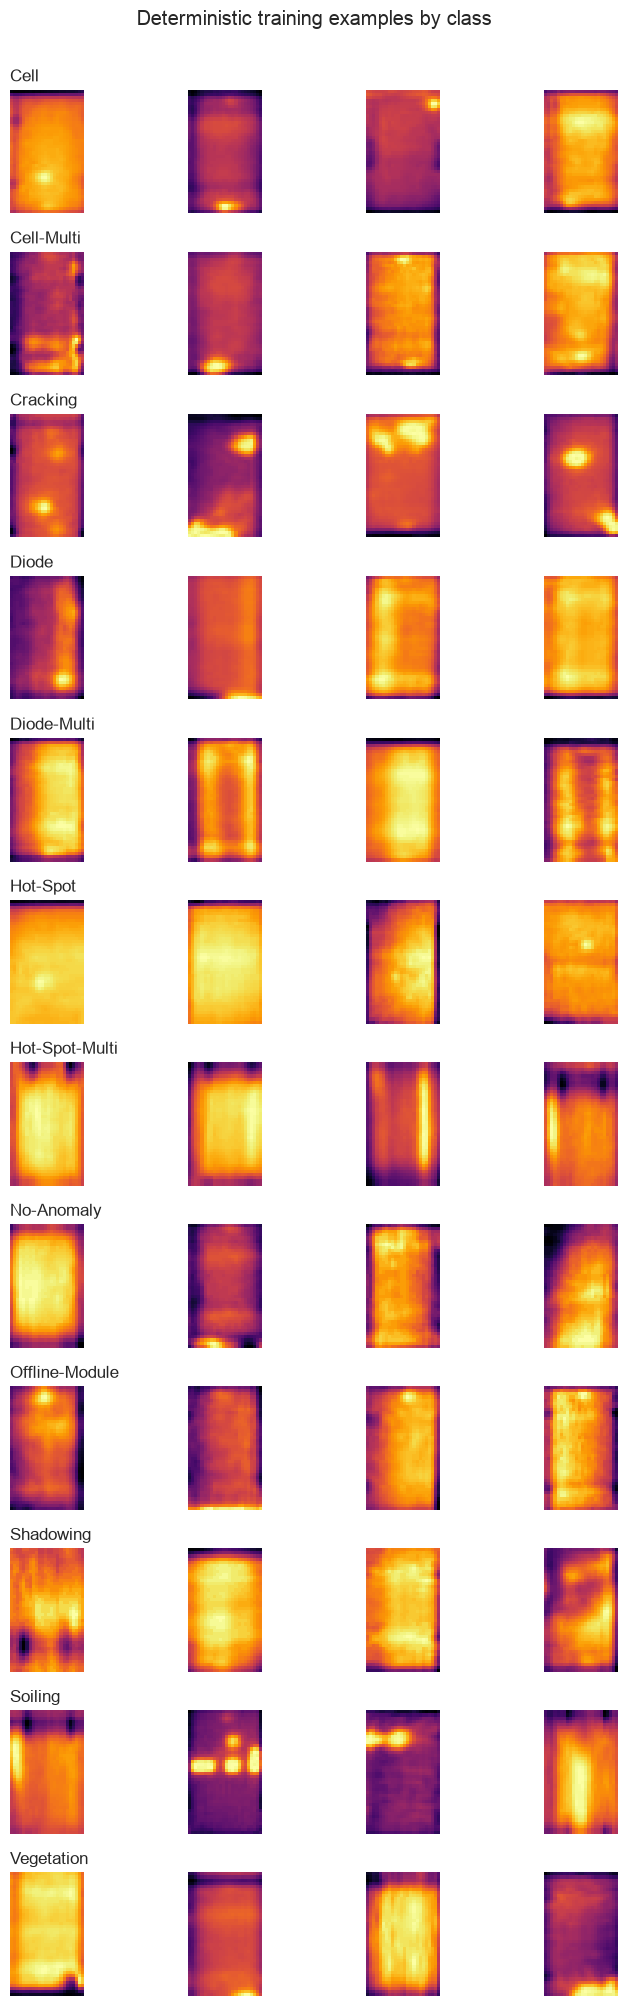

In [23]:
eda_df = splits["train"]
labels = sorted(eda_df["label"].unique())
fig, axes = plt.subplots(len(labels), 4, figsize=(8, 20))
for row_index, label in enumerate(labels):
    examples = eda_df[eda_df["label"] == label].sample(
        4,
        random_state=SEED,
    )
    for column_index, row in enumerate(examples.itertuples(index=False)):
        with Image.open(row.absolute_path) as image:
            axes[row_index, column_index].imshow(image, cmap="inferno")
        axes[row_index, column_index].axis("off")
        if column_index == 0:
            axes[row_index, column_index].set_title(label, loc="left")
fig.suptitle(
    "Deterministic training examples by class",
    y=1.002,
)
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "class_samples.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

## Data Preprocessing

Images are converted from grayscale to three-channel RGB, resized from 24 × 40 to 128 × 128 pixels, converted to tensors, and normalized using ImageNet statistics. No data augmentation is used in the baseline experiment.

In [24]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

model_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

label_names = sorted(splits["train"]["label"].unique())
label_to_index = {label: index for index, label in enumerate(label_names)}
index_to_label = {index: label for label, index in label_to_index.items()}

display(pd.DataFrame(
    [{"label": label, "class_index": index} for label, index in label_to_index.items()]
))


,label,class_index
0,Cell,0
1,Cell-Multi,1
2,Cracking,2
3,Diode,3
4,Diode-Multi,4
5,Hot-Spot,5
6,Hot-Spot-Multi,6
7,No-Anomaly,7
8,Offline-Module,8
9,Shadowing,9


In [25]:
class ManifestDataset(Dataset):
    def __init__(self, frame, transform):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        with Image.open(DATA_DIR / row["image_filepath"]) as image:
            tensor = self.transform(image.convert("RGB"))
        label = torch.tensor(
            label_to_index[row["label"]],
            dtype=torch.long,
        )
        return tensor, label


In [26]:
train_counts = splits["train"]["label"].value_counts().to_dict()
training_distribution = (
    splits["train"]["label"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="training_records")
)
training_distribution["percentage"] = (
    training_distribution["training_records"] / len(splits["train"]) * 100
)
display(training_distribution)


,label,training_records,percentage
0,No-Anomaly,7000,50.067949
1,Cell,1313,9.391317
2,Vegetation,1147,8.203991
3,Diode,1047,7.488735
4,Cell-Multi,900,6.437308
5,Shadowing,732,5.235677
6,Cracking,656,4.692082
7,Offline-Module,575,4.112724
8,Hot-Spot,174,1.244546
9,Hot-Spot-Multi,172,1.230241


In [27]:
def make_loader(frame, transform, shuffle=False):
    return DataLoader(
        ManifestDataset(frame, transform),
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )


In [28]:
train_loader = make_loader(
    splits["train"],
    model_transform,
    shuffle=True,
)
validation_loader = make_loader(
    splits["validation"],
    model_transform,
)
print(
    f"Data loaders: {len(train_loader)} training and "
    f"{len(validation_loader)} validation batches"
)


Data loaders: 110 training and 24 validation batches


In [ ]:
batch_images, batch_labels = next(iter(train_loader))
print(f"Batch tensor shape: {tuple(batch_images.shape)}")
print(f"Batch data type: {batch_images.dtype}")
print(
    f"Batch value range: {batch_images.min().item():.3f} to "
    f"{batch_images.max().item():.3f}"
)
display(pd.DataFrame({
    "class_index": batch_labels[:10].tolist(),
    "label": [index_to_label[int(value)] for value in batch_labels[:10]],
}))
del batch_images, batch_labels

## Model Training

An ImageNet-pretrained ResNet-18 is adapted to 12 classes and trained with cross-entropy loss and AdamW. Three training epochs are used, and the epoch with the highest validation macro-F1 is selected. The test set is not used during training or model selection.

In [29]:
def build_model(num_classes, pretrained=True):
    weights = ResNet18_Weights.DEFAULT if pretrained else None
    model = resnet18(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


In [30]:
def metric_dict(targets, predictions):
    labels = np.arange(len(label_names))
    precision, recall, f1, support = precision_recall_fscore_support(
        targets,
        predictions,
        labels=labels,
        zero_division=0,
    )
    rare_positions = [label_to_index[label] for label in sorted(RARE_CLASSES)]
    return {
        "accuracy": float(accuracy_score(targets, predictions)),
        "balanced_accuracy": float(balanced_accuracy_score(targets, predictions)),
        "macro_precision": float(precision.mean()),
        "macro_recall": float(recall.mean()),
        "macro_f1": float(f1.mean()),
        "mean_rare_class_recall": float(recall[rare_positions].mean()),
        "records": int(support.sum()),
    }


In [31]:
def per_class_metrics(targets, predictions, method):
    precision, recall, f1, support = precision_recall_fscore_support(
        targets,
        predictions,
        labels=np.arange(len(label_names)),
        zero_division=0,
    )
    return pd.DataFrame({
        "method": method,
        "label": label_names,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": support,
        "is_rare_target": [label in RARE_CLASSES for label in label_names],
    })


In [32]:
def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train(training)
    losses = []
    y_true = []
    y_pred = []

    context = torch.enable_grad() if training else torch.no_grad()
    with context:
        for images, targets in loader:
            images = images.to(DEVICE)
            targets = targets.to(DEVICE)
            if training:
                optimizer.zero_grad(set_to_none=True)

            logits = model(images)
            loss = criterion(logits, targets)
            if training:
                loss.backward()
                optimizer.step()

            losses.append(
                float(loss.detach().cpu()) * images.size(0)
            )
            predictions = logits.argmax(dim=1)
            y_true.extend(
                targets.detach().cpu().numpy().tolist()
            )
            y_pred.extend(
                predictions.detach().cpu().numpy().tolist()
            )

    return {
        "loss": sum(losses) / len(loader.dataset),
        "targets": np.asarray(y_true),
        "predictions": np.asarray(y_pred),
    }


In [33]:
def predict_logits(model, loader, criterion):
    model.eval()
    losses = []
    target_parts = []
    logit_parts = []
    with torch.no_grad():
        for images, targets in loader:
            images = images.to(DEVICE)
            targets = targets.to(DEVICE)
            logits = model(images)
            loss = criterion(logits, targets)
            losses.append(
                float(loss.detach().cpu()) * images.size(0)
            )
            target_parts.append(
                targets.detach().cpu().numpy()
            )
            logit_parts.append(
                logits.detach().cpu().numpy()
            )

    targets_np = np.concatenate(target_parts)
    logits_np = np.concatenate(logit_parts)
    return {
        "loss": sum(losses) / len(loader.dataset),
        "targets": targets_np,
        "logits": logits_np,
        "predictions": logits_np.argmax(axis=1),
    }


In [34]:
model = build_model(len(label_names), pretrained=True).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)
trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

In [ ]:
print("Model: ResNet-18")
print(f"Output classes: {len(label_names)}")
print(f"Trainable parameters: {trainable_parameters:,}")


In [35]:
history = []
best_state = None
best_epoch = 0
best_macro_f1 = -1.0
training_started = time.perf_counter()

print(f"Training for {EPOCHS} epoch(s) on {DEVICE}.")

Training for 3 epoch(s) on mps.


In [36]:
for epoch in range(1, EPOCHS + 1):
    train_result = run_epoch(
        model,
        train_loader,
        criterion,
        optimizer=optimizer,
    )
    validation_result = run_epoch(
        model,
        validation_loader,
        criterion,
    )
    train_metrics = metric_dict(
        train_result["targets"],
        train_result["predictions"],
    )
    validation_metrics = metric_dict(
        validation_result["targets"],
        validation_result["predictions"],
    )
    row = {
        "epoch": epoch,
        "train_loss": train_result["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "eval_loss": validation_result["loss"],
        "eval_accuracy": validation_metrics["accuracy"],
        "eval_macro_f1": validation_metrics["macro_f1"],
    }
    history.append(row)
    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"train loss: {row['train_loss']:.4f} | "
        f"train macro-F1: {row['train_macro_f1']:.4f} | "
        f"validation loss: {row['eval_loss']:.4f} | "
        f"validation macro-F1: {row['eval_macro_f1']:.4f}"
    )

    if validation_metrics["macro_f1"] > best_macro_f1:
        best_macro_f1 = validation_metrics["macro_f1"]
        best_epoch = epoch
        best_state = deepcopy({
            key: value.detach().cpu()
            for key, value in model.state_dict().items()
        })

Epoch 1/3 | train loss: 0.9246 | train macro-F1: 0.4603 | validation loss: 0.8588 | validation macro-F1: 0.4950
Epoch 2/3 | train loss: 0.5819 | train macro-F1: 0.6543 | validation loss: 0.6984 | validation macro-F1: 0.6216
Epoch 3/3 | train loss: 0.4240 | train macro-F1: 0.7510 | validation loss: 0.7090 | validation macro-F1: 0.6237


In [37]:
if best_state is None:
    raise RuntimeError("Training did not produce a checkpoint.")

model.load_state_dict(best_state)
model.to(DEVICE)
training_seconds = time.perf_counter() - training_started

In [ ]:
history_df = pd.DataFrame(history)
history_df.to_csv(
    OUTPUT_DIR / "training_history.csv",
    index=False,
)
print(
    f"Best epoch: {best_epoch} | "
    f"Training time: {training_seconds / 60:.1f} minutes"
)

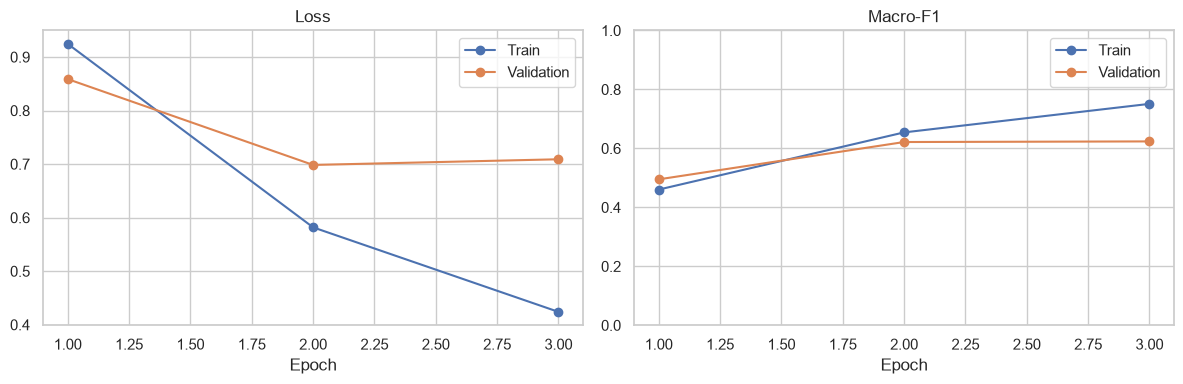

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train")
axes[0].plot(history_df["epoch"], history_df["eval_loss"], marker="o", label="Validation")
axes[0].set(title="Loss", xlabel="Epoch")
axes[0].legend()
axes[1].plot(history_df["epoch"], history_df["train_macro_f1"], marker="o", label="Train")
axes[1].plot(history_df["epoch"], history_df["eval_macro_f1"], marker="o", label="Validation")
axes[1].set(title="Macro-F1", xlabel="Epoch", ylim=(0, 1))
axes[1].legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "training_curves.png", dpi=180, bbox_inches="tight")
plt.show()


### Training Results

For the recorded run, validation macro-F1 increases from 0.4950 in epoch 1 to 0.6237 in epoch 3, so epoch 3 is retained. Because the best value occurs at the final epoch, the three-epoch run does not establish convergence.

## Validation Set Evaluation

Logit adjustment changes the class scores without retraining the model. For class $c$, the adjusted score is

$$
z'_c = z_c - \tau \log(\pi_c),
$$

where $z_c$ is the model score, $\pi_c$ is the class proportion in the training set, and $\tau$ controls the adjustment strength. Smaller class proportions therefore receive a larger relative adjustment.

Values of $\tau$ from 0.0 to 1.5 are evaluated on the validation set. The selected value has the highest macro-F1 among values that improve macro-F1 and increase mean rare-class recall by at least 0.10.

In [39]:
validation_result = predict_logits(model, validation_loader, criterion)
train_prior = np.array(
    [train_counts[label] / len(splits["train"]) for label in label_names],
    dtype=np.float64,
)
unadjusted_validation = metric_dict(
    validation_result["targets"],
    validation_result["predictions"],
)
display(pd.DataFrame([unadjusted_validation], index=["Baseline validation"]))


,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,mean_rare_class_recall,records
Baseline validation,0.785381,0.570869,0.752118,0.570869,0.623668,0.459015,2996


In [40]:
def adjusted_predictions(logits, tau):
    return (logits - float(tau) * np.log(train_prior)[None, :]).argmax(axis=1)


In [41]:
sweep_rows = []
for tau in TAU_VALUES:
    predictions = adjusted_predictions(validation_result["logits"], tau)
    sweep_rows.append({
        "tau": float(tau),
        **metric_dict(validation_result["targets"], predictions),
    })

sweep_df = pd.DataFrame(sweep_rows)
baseline_sweep = sweep_df.iloc[0]

In [ ]:
display(
    sweep_df[[
        "tau",
        "accuracy",
        "balanced_accuracy",
        "macro_f1",
        "mean_rare_class_recall",
    ]].round(4)
)

In [42]:
sweep_df["delta_accuracy_vs_baseline"] = (
    sweep_df["accuracy"] - baseline_sweep["accuracy"]
)
sweep_df["delta_macro_f1_vs_baseline"] = (
    sweep_df["macro_f1"] - baseline_sweep["macro_f1"]
)
sweep_df["delta_rare_recall_vs_baseline"] = (
    sweep_df["mean_rare_class_recall"]
    - baseline_sweep["mean_rare_class_recall"]
)
candidates = sweep_df[
    (sweep_df["delta_macro_f1_vs_baseline"] > 0)
    & (sweep_df["delta_rare_recall_vs_baseline"] >= 0.10)
]

In [ ]:
print(f"Candidate tau values: {len(candidates)}")
display(
    candidates.sort_values(
        "macro_f1",
        ascending=False,
    )[[
        "tau",
        "accuracy",
        "macro_f1",
        "mean_rare_class_recall",
        "delta_macro_f1_vs_baseline",
        "delta_rare_recall_vs_baseline",
    ]].round(4)
)

In [43]:
if candidates.empty:
    selected = sweep_df.sort_values(
        "macro_f1",
        ascending=False,
    ).iloc[0]
    selection_rule = "highest validation macro-F1"
else:
    selected = candidates.sort_values(
        "macro_f1",
        ascending=False,
    ).iloc[0]
    selection_rule = (
        "highest validation macro-F1 among values "
        "with at least +0.10 rare recall"
    )

SELECTED_TAU = float(selected["tau"])
print(f"Selection rule: {selection_rule}.")

Selection rule: highest validation macro-F1 among values with at least +0.10 rare recall.


In [44]:
sweep_df.to_csv(
    OUTPUT_DIR / "validation_logit_adjustment_sweep.csv",
    index=False,
)
display(pd.DataFrame([
    {"method": "baseline", **baseline_sweep.to_dict()},
    {"method": "logit_adjustment", **selected.to_dict()},
]).set_index("method"))
print(f"Selected tau: {SELECTED_TAU:.1f}")

,tau,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,mean_rare_class_recall,records,delta_accuracy_vs_baseline,delta_macro_f1_vs_baseline,delta_rare_recall_vs_baseline
method,,,,,,,,,,,
baseline,0.0,0.785381,0.570869,0.752118,0.570869,0.623668,0.459015,2996.0,NaN,NaN,NaN
logit_adjustment,0.6,0.786716,0.630364,0.657485,0.630364,0.632437,0.561943,2996.0,0.001335,0.008769,0.102927


Selected tau: 0.6


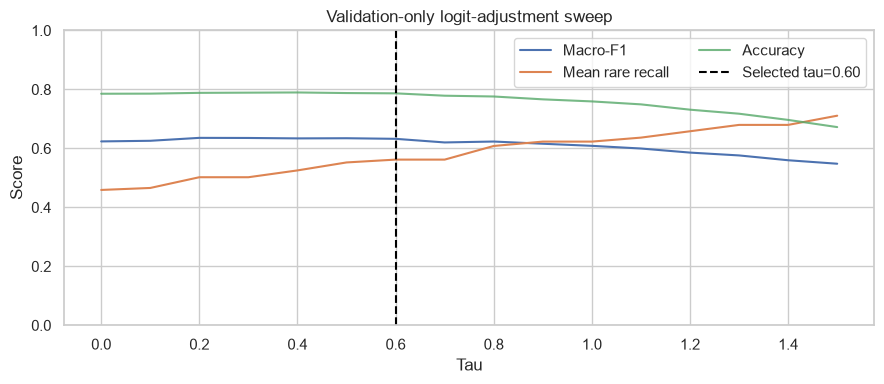

In [45]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sweep_df["tau"], sweep_df["macro_f1"], label="Macro-F1")
ax.plot(sweep_df["tau"], sweep_df["mean_rare_class_recall"], label="Mean rare recall")
ax.plot(sweep_df["tau"], sweep_df["accuracy"], label="Accuracy", alpha=0.8)
ax.axvline(SELECTED_TAU, color="black", linestyle="--", label=f"Selected tau={SELECTED_TAU:.2f}")
ax.set(title="Validation-only logit-adjustment sweep", xlabel="Tau", ylabel="Score", ylim=(0, 1))
ax.legend(ncol=2)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "logit_adjustment_sweep.png", dpi=180, bbox_inches="tight")
plt.show()


### Validation Results

For the recorded run, the selected value is $\tau = 0.6$. Relative to the unadjusted checkpoint, validation macro-F1 increases from 0.6237 to 0.6324, mean rare-class recall increases from 0.4590 to 0.5619, and accuracy changes from 0.7854 to 0.7867. The selected value is then used for the test evaluation.

## Test Set Evaluation

Baseline and adjusted predictions are generated from the same checkpoint. This isolates the effect of the decision rule. The selected value of tau is fixed before testing. Aggregate metrics, per-class metrics, a confusion matrix, record-level predictions, and bootstrap intervals are reported.

The test set is held out from training, model selection, and tau selection in this notebook. It was inspected during an earlier project comparison, so these results are treated as follow-up evidence.

In [46]:
test_loader = make_loader(
    splits["test"],
    model_transform,
)
test_result = predict_logits(model, test_loader, criterion)
test_result["image_ids"] = splits["test"]["image_id"].to_numpy()

print(f"Generated logits for {len(test_result['targets']):,} test records.")

Generated logits for 2,995 test records.


In [47]:
test_baseline_predictions = test_result["predictions"]
test_adjusted_predictions = adjusted_predictions(
    test_result["logits"],
    SELECTED_TAU,
)
test_baseline_metrics = metric_dict(
    test_result["targets"],
    test_baseline_predictions,
)
test_adjusted_metrics = metric_dict(
    test_result["targets"],
    test_adjusted_predictions,
)

In [48]:
test_metrics_df = pd.DataFrame([
    {
        "method": "baseline",
        "split": "test",
        "tau": 0.0,
        **test_baseline_metrics,
    },
    {
        "method": "logit_adjustment",
        "split": "test",
        "tau": round(SELECTED_TAU, 10),
        **test_adjusted_metrics,
    },
])
baseline_row = test_metrics_df.iloc[0]
for metric in (
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "mean_rare_class_recall",
):
    test_metrics_df[f"delta_{metric}_vs_baseline"] = (
        test_metrics_df[metric] - baseline_row[metric]
    )
test_metrics_df.to_csv(
    OUTPUT_DIR / "test_metrics.csv",
    index=False,
)
display(test_metrics_df.set_index("method"))

,split,tau,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,mean_rare_class_recall,records,delta_accuracy_vs_baseline,delta_balanced_accuracy_vs_baseline,delta_macro_f1_vs_baseline,delta_mean_rare_class_recall_vs_baseline
method,,,,,,,,,,,,,
baseline,test,0.0,0.798331,0.570026,0.717455,0.570026,0.611688,0.399925,2995,0.000000,0.000000,0.000000,0.000000
logit_adjustment,test,0.6,0.795659,0.639373,0.648912,0.639373,0.633836,0.546471,2995,-0.002671,0.069346,0.022148,0.146547


In [49]:
test_per_class_df = pd.concat([
    per_class_metrics(
        test_result["targets"],
        test_baseline_predictions,
        "baseline",
    ),
    per_class_metrics(
        test_result["targets"],
        test_adjusted_predictions,
        "logit_adjustment",
    ),
], ignore_index=True)
test_per_class_df.to_csv(
    OUTPUT_DIR / "test_per_class_metrics.csv",
    index=False,
)
display(
    test_per_class_df[
        test_per_class_df["method"] == "logit_adjustment"
    ].sort_values("f1")
)


,method,label,precision,recall,f1,support,is_rare_target
22,logit_adjustment,Soiling,0.290323,0.300000,0.295082,30,True
18,logit_adjustment,Hot-Spot-Multi,0.316456,0.675676,0.431034,37,True
17,logit_adjustment,Hot-Spot,0.457143,0.432432,0.444444,37,True
13,logit_adjustment,Cell-Multi,0.515528,0.430052,0.468927,193,False
14,logit_adjustment,Cracking,0.747253,0.485714,0.588745,140,False
21,logit_adjustment,Shadowing,0.728814,0.551282,0.627737,156,False
20,logit_adjustment,Offline-Module,0.632353,0.699187,0.664093,123,False
12,logit_adjustment,Cell,0.655629,0.702128,0.678082,282,False
23,logit_adjustment,Vegetation,0.643636,0.722449,0.680769,245,False
16,logit_adjustment,Diode-Multi,0.954545,0.777778,0.857143,27,True


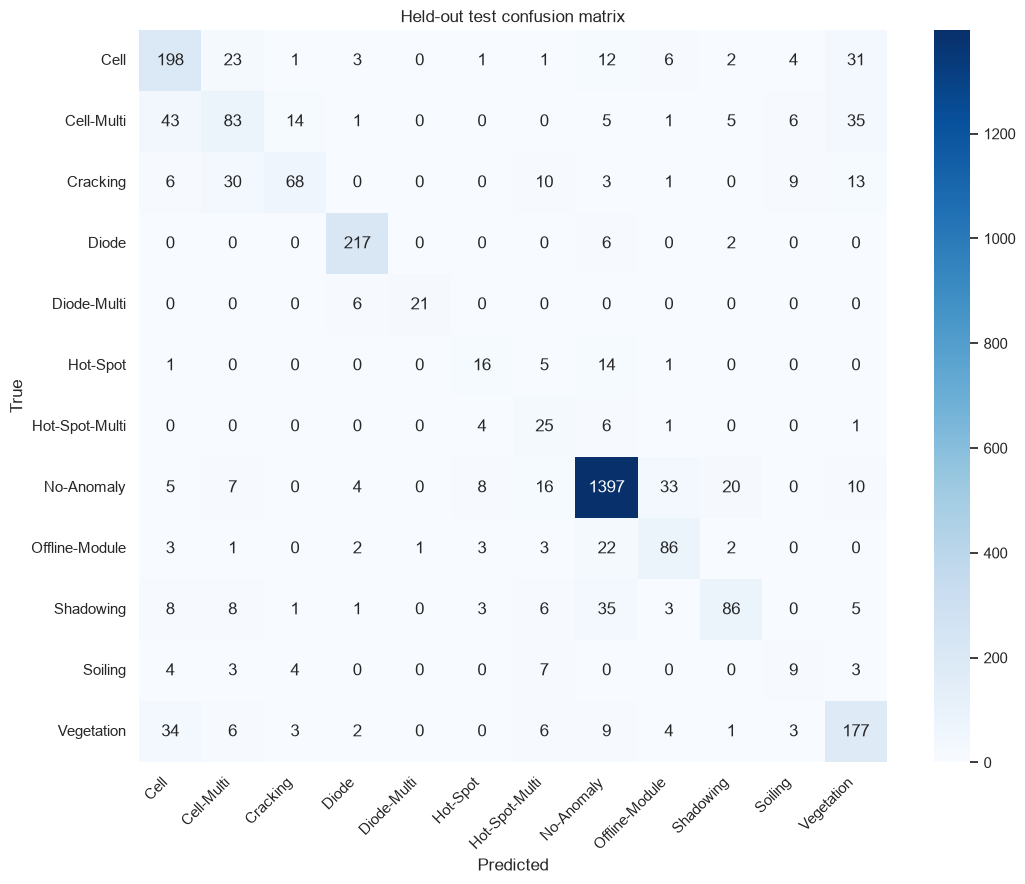

In [50]:
matrix = confusion_matrix(
    test_result["targets"], test_adjusted_predictions, labels=np.arange(len(label_names))
)
pd.DataFrame(matrix, index=label_names, columns=label_names).to_csv(OUTPUT_DIR / "test_confusion_matrix.csv")
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names, ax=ax)
ax.set(title="Held-out test confusion matrix", xlabel="Predicted", ylabel="True")
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "test_confusion_matrix.png", dpi=180, bbox_inches="tight")
plt.show()


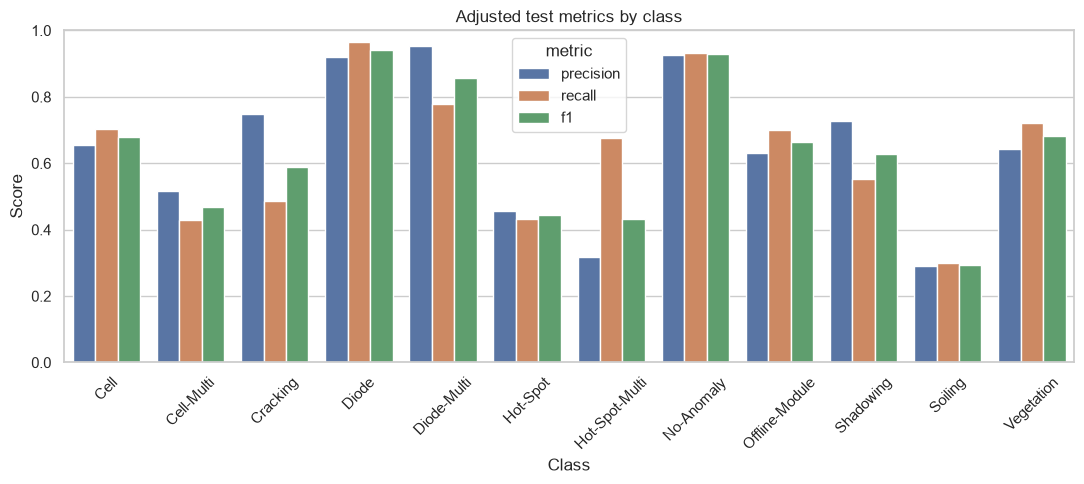

In [51]:
adjusted_per_class = test_per_class_df[
    test_per_class_df["method"] == "logit_adjustment"
]
plot_frame = adjusted_per_class.melt(
    id_vars=["label", "is_rare_target"],
    value_vars=["precision", "recall", "f1"],
    var_name="metric",
    value_name="score",
)
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=plot_frame, x="label", y="score", hue="metric", ax=ax)
ax.set(
    title="Adjusted test metrics by class",
    xlabel="Class",
    ylabel="Score",
    ylim=(0, 1),
)
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "test_per_class_metrics.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()


In [52]:
id_to_position = {
    int(image_id): position
    for position, image_id in enumerate(test_result["image_ids"])
}
prediction_rows = []
for row in splits["test"].itertuples(index=False):
    position = id_to_position[int(row.image_id)]
    prediction_rows.append({
        "image_id": int(row.image_id),
        "image_filepath": row.image_filepath,
        "label": row.label,
        "baseline_prediction": index_to_label[
            int(test_baseline_predictions[position])
        ],
        "adjusted_prediction": index_to_label[
            int(test_adjusted_predictions[position])
        ],
    })

test_predictions_df = pd.DataFrame(prediction_rows)
test_predictions_df.to_csv(
    OUTPUT_DIR / "test_predictions.csv",
    index=False,
)
print(f"Saved {len(test_predictions_df):,} test predictions")
display(test_predictions_df.head(10))


Saved 2,995 test predictions


,image_id,image_filepath,label,baseline_prediction,adjusted_prediction
0,2,images/2.jpg,Offline-Module,Offline-Module,Offline-Module
1,4,images/4.jpg,Offline-Module,No-Anomaly,Offline-Module
2,12,images/12.jpg,Offline-Module,Offline-Module,Offline-Module
3,13,images/13.jpg,Offline-Module,Offline-Module,Offline-Module
4,18,images/18.jpg,Offline-Module,No-Anomaly,No-Anomaly
5,20,images/20.jpg,Offline-Module,Diode,Diode
6,21,images/21.jpg,Offline-Module,No-Anomaly,Offline-Module
7,25,images/25.jpg,Offline-Module,Offline-Module,Offline-Module
8,36,images/36.jpg,Offline-Module,Offline-Module,Offline-Module
9,45,images/45.jpg,Offline-Module,No-Anomaly,No-Anomaly


In [53]:
def class_recall(targets, predictions, labels):
    return recall_score(
        targets,
        predictions,
        labels=labels,
        average=None,
        zero_division=0,
    )

In [54]:
def metric_deltas(targets, baseline, adjusted, labels):
    rare_positions = [
        labels.index(label)
        for label in sorted(RARE_CLASSES)
    ]
    baseline_recall = class_recall(targets, baseline, labels)
    adjusted_recall = class_recall(targets, adjusted, labels)
    return {
        "accuracy": (
            accuracy_score(targets, adjusted)
            - accuracy_score(targets, baseline)
        ),
        "balanced_accuracy": (
            adjusted_recall.mean()
            - baseline_recall.mean()
        ),
        "macro_f1": (
            f1_score(
                targets,
                adjusted,
                labels=labels,
                average="macro",
                zero_division=0,
            )
            - f1_score(
                targets,
                baseline,
                labels=labels,
                average="macro",
                zero_division=0,
            )
        ),
        "mean_rare_class_recall": (
            adjusted_recall[rare_positions].mean()
            - baseline_recall[rare_positions].mean()
        ),
    }

In [55]:
def sample_stratified_indices(class_indices, rng):
    return np.concatenate([
        rng.choice(
            indices,
            size=len(indices),
            replace=True,
        )
        for indices in class_indices
    ])

In [56]:
def paired_stratified_bootstrap(
    targets,
    baseline,
    adjusted,
    labels,
    iterations,
    seed,
):
    class_indices = [
        np.flatnonzero(targets == label)
        for label in labels
    ]
    rng = np.random.default_rng(seed)
    samples = {
        metric: []
        for metric in (
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "mean_rare_class_recall",
        )
    }
    for _ in range(iterations):
        sampled = sample_stratified_indices(class_indices, rng)
        values = metric_deltas(
            targets[sampled],
            baseline[sampled],
            adjusted[sampled],
            labels,
        )
        for metric, value in values.items():
            samples[metric].append(value)

    observed = metric_deltas(
        targets,
        baseline,
        adjusted,
        labels,
    )
    rows = []
    for metric, values in samples.items():
        array = np.asarray(values)
        rows.append({
            "metric": metric,
            "observed_delta": observed[metric],
            "bootstrap_mean_delta": array.mean(),
            "ci_95_low": np.quantile(array, 0.025),
            "ci_95_high": np.quantile(array, 0.975),
            "proportion_positive": (array > 0).mean(),
            "iterations": iterations,
            "seed": seed,
            "bootstrap_type": "paired stratified by true class",
        })
    return pd.DataFrame(rows)

In [57]:
string_targets = test_predictions_df["label"].to_numpy()
string_baseline = test_predictions_df["baseline_prediction"].to_numpy()
string_adjusted = test_predictions_df["adjusted_prediction"].to_numpy()

print(
    f"Running {BOOTSTRAP_ITERATIONS:,} paired class-stratified "
    "bootstrap iterations."
)
bootstrap_df = paired_stratified_bootstrap(
    string_targets,
    string_baseline,
    string_adjusted,
    label_names,
    BOOTSTRAP_ITERATIONS,
    SEED,
)
bootstrap_df.to_csv(
    OUTPUT_DIR / "test_bootstrap_summary.csv",
    index=False,
)
display(bootstrap_df)

Running 2,000 paired class-stratified bootstrap iterations.


,metric,observed_delta,bootstrap_mean_delta,ci_95_low,ci_95_high,proportion_positive,iterations,seed,bootstrap_type
0,accuracy,-0.002671,-0.002787,-0.010684,0.005342,0.242,2000,42,paired stratified by true class
1,balanced_accuracy,0.069346,0.069021,0.047389,0.091929,1.000,2000,42,paired stratified by true class
2,macro_f1,0.022148,0.022645,0.002431,0.044122,0.983,2000,42,paired stratified by true class
3,mean_rare_class_recall,0.146547,0.145803,0.084985,0.209794,1.000,2000,42,paired stratified by true class


### Test Results and Error Analysis

The following values are from the recorded seed-42 run.

| Metric | Baseline | Adjusted | Change |
|---|---:|---:|---:|
| Accuracy | 0.7983 | 0.7957 | −0.0027 |
| Balanced accuracy | 0.5700 | 0.6394 | +0.0693 |
| Macro-F1 | 0.6117 | 0.6338 | +0.0221 |
| Mean rare-class recall | 0.3999 | 0.5465 | +0.1465 |

The paired bootstrap intervals for the changes are [0.0474, 0.0919] for balanced accuracy, [0.0024, 0.0441] for macro-F1, [0.0850, 0.2098] for mean rare-class recall, and [−0.0107, 0.0053] for accuracy. These intervals describe variation in the fixed test predictions and do not include variation from new training runs, splits, sites, cameras, or datasets.

Rows in the confusion matrix represent true classes and columns represent predicted classes. The adjustment improves rare-class recall but can reduce precision. For example, Hot-Spot-Multi recall is 0.6757 with precision 0.3165, while Soiling remains the weakest adjusted class with recall 0.3000 and precision 0.2903.

## Model Interpretation

Grad-CAM is used to visualise image regions that contribute to a target-class score. The first correctly classified rare-class test image is selected using a deterministic rule. If no such image is available, the first rare-class test image is used.

This is a qualitative diagnostic based on one image. Because the dataset has image-level labels rather than pixel-level masks, the heatmap cannot confirm localisation accuracy.

In [58]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        self.forward_handle = target_layer.register_forward_hook(
            self._capture_activations
        )
        self.backward_handle = target_layer.register_full_backward_hook(
            self._capture_gradients
        )

    def _capture_activations(self, module, inputs, output):
        self.activations = output

    def _capture_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def __call__(self, input_tensor, target_index):
        self.model.eval()
        self.model.zero_grad(set_to_none=True)
        scores = self.model(input_tensor)
        scores[0, target_index].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = torch.relu(
            (weights * self.activations).sum(dim=1)
        ).squeeze()
        cam = cam.detach().cpu().numpy()
        return (
            (cam - cam.min())
            / max(float(cam.max() - cam.min()), 1e-8)
        )

    def close(self):
        self.forward_handle.remove()
        self.backward_handle.remove()


In [59]:
rare_examples = test_predictions_df[
    test_predictions_df["label"].isin(RARE_CLASSES)
].sort_values("image_id").copy()
correct_rare = rare_examples[
    rare_examples["label"] == rare_examples["adjusted_prediction"]
]
example_pool = correct_rare if not correct_rare.empty else rare_examples
example_row = example_pool.iloc[0]
example_path = DATA_DIR / example_row["image_filepath"]
target_index = label_to_index[example_row["adjusted_prediction"]]

with Image.open(example_path) as image:
    original_image = image.convert("RGB")
    input_tensor = model_transform(original_image).unsqueeze(0).to(DEVICE)

gradcam = GradCAM(model, model.layer4[-1])
cam = gradcam(input_tensor, target_index)
gradcam.close()
cam_image = Image.fromarray(np.uint8(cam * 255)).resize(
    original_image.size,
    Image.Resampling.BILINEAR,
)
display(example_row.to_frame(name="value"))


,value
image_id,827
image_filepath,images/827.jpg
label,Diode-Multi
baseline_prediction,Diode-Multi
adjusted_prediction,Diode-Multi


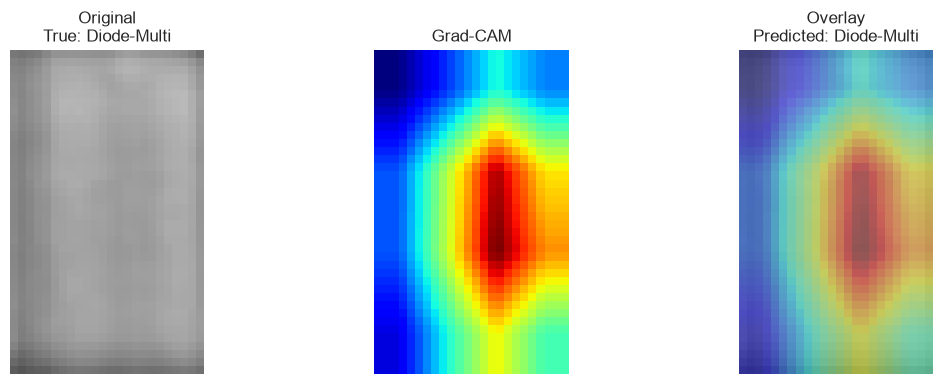

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(original_image, cmap="inferno")
axes[0].set_title(f"Original\nTrue: {example_row['label']}")
axes[1].imshow(cam_image, cmap="jet")
axes[1].set_title("Grad-CAM")
axes[2].imshow(original_image, cmap="gray")
axes[2].imshow(cam_image, cmap="jet", alpha=0.45)
axes[2].set_title(f"Overlay\nPredicted: {example_row['adjusted_prediction']}")
for ax in axes:
    ax.axis("off")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "gradcam_example.png", dpi=200, bbox_inches="tight")
plt.show()


## Saving Results

The main experiment saves the model checkpoint, experiment settings, data summaries, data splits, predictions, metrics, bootstrap results, and figures. A SHA-256 file manifest is created before the results are packaged. The additional validation results are saved separately after that section.

In [61]:
def split_fingerprint(frame):
    records = (
        frame.sort_values("image_id")[["image_id", "sha256", "label"]]
        .astype(str)
        .agg("|".join, axis=1)
    )
    payload = "\n".join(records).encode("utf-8")
    return hashlib.sha256(payload).hexdigest()

In [62]:
experiment_config = {
    "dataset_url": DATASET_URL,
    "dataset_sha256": EXPECTED_SHA256,
    "image_content_hash": "sha256",
    "seed": SEED,
    "quick_run": QUICK_RUN,
    "model": "torchvision.resnet18",
    "pretrained": True,
    "image_size": IMAGE_SIZE,
    "source_image_size": [24, 40],
    "resize_policy": "direct square resize",
    "augmentation": "none",
    "normalization_mean": IMAGENET_MEAN,
    "normalization_std": IMAGENET_STD,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "best_epoch": best_epoch,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "selected_tau": SELECTED_TAU,
    "selection_rule": selection_rule,
    "label_to_index": label_to_index,
    "class_priors": {
        label: float(train_prior[index])
        for index, label in enumerate(label_names)
    },
    "rare_classes": sorted(RARE_CLASSES),
    "training_seconds": training_seconds,
}

In [63]:
experiment_config.update({
    "device": str(DEVICE),
    "package_versions": {
        "python": platform.python_version(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scikit_learn": package_version("scikit-learn"),
        "torch": torch.__version__,
        "torchvision": package_version("torchvision"),
        "pillow": package_version("Pillow"),
    },
    "split_policy": (
        "70/15/15 deterministic class-stratified split "
        "after exact-duplicate policy"
    ),
    "split_fingerprints_sha256": {
        name: split_fingerprint(frame)
        for name, frame in splits.items()
    },
    "test_used_for_training_or_tau_selection": False,
    "test_loader_created_after_tau_selection": True,
    "test_evidence_status": (
        "follow-up evidence; test inspected in an earlier "
        "class-weighting comparison"
    ),
    "bootstrap_scope": (
        "paired class-stratified resampling of fixed test predictions; "
        "does not include training, split, site, or device variation"
    ),
})

print("Experiment configuration assembled.")

Experiment configuration assembled.


In [64]:
with (OUTPUT_DIR / "experiment_config.json").open(
    "w",
    encoding="utf-8",
) as handle:
    json.dump(experiment_config, handle, indent=2)
with (OUTPUT_DIR / "dataset_summary.json").open(
    "w",
    encoding="utf-8",
) as handle:
    json.dump(summary, handle, indent=2)

print("Experiment configuration and dataset summary saved.")

Experiment configuration and dataset summary saved.


In [65]:
checkpoint_path = OUTPUT_DIR / "pv_fault_resnet18.pt"
torch.save({
    "schema_version": 1,
    "model_state_dict": {
        key: value.detach().cpu()
        for key, value in model.state_dict().items()
    },
    "architecture": "resnet18",
    "image_size": IMAGE_SIZE,
    "normalization_mean": IMAGENET_MEAN,
    "normalization_std": IMAGENET_STD,
    "label_to_index": label_to_index,
    "class_priors": train_prior,
    "selected_tau": SELECTED_TAU,
}, checkpoint_path)
print("Model and experiment settings saved.")

Model and experiment settings saved.


In [66]:
manifest_path = OUTPUT_DIR / "artifact_manifest.json"
manifest = {}
for path in sorted(OUTPUT_DIR.iterdir()):
    if path.is_file() and path != manifest_path:
        manifest[path.name] = {
            "sha256": sha256_file(path),
            "bytes": path.stat().st_size,
        }
with manifest_path.open("w", encoding="utf-8") as handle:
    json.dump(manifest, handle, indent=2)

print(f"Artifact manifest saved: {manifest_path.name}")

Artifact manifest saved: artifact_manifest.json


In [67]:
bundle_path = WORK_DIR / "pv_fault_classification_artifacts.zip"
with zipfile.ZipFile(
    bundle_path,
    "w",
    compression=zipfile.ZIP_DEFLATED,
) as bundle:
    for path in sorted(OUTPUT_DIR.iterdir()):
        if path.is_file():
            bundle.write(path, arcname=path.name)

print(f"Results archive created: {bundle_path.name}")

Results archive created: pv_fault_classification_artifacts.zip


In [68]:
try:
    from google.colab import files

    files.download(str(bundle_path))
except ImportError:
    print(f"Archive available locally at: {bundle_path}")

Archive available locally at: /tmp/pv_fault_colab/pv_fault_classification_artifacts.zip
